# DistilBERT — Toxic Comment Classification

This notebook fine-tunes DistilBERT on the Jigsaw dataset for binary toxicity detection.
DistilBERT is a smaller, faster version of BERT that retains ~97% of its performance.
Unlike the NBOW+LR model, DistilBERT captures word context, so it can potentially
handle sarcasm and negation better.

**Prereq:** Run `notebooks/preprocessing.ipynb` first to generate the split CSVs.

In [7]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data_utils import load_splits, split_summary, RANDOM_SEED
from src.distilbert_model import (
    train_distilbert,
    predict,
    plot_training_curves,
    save_model,
    get_device,
    MAX_LEN,
)
from src.evaluation import evaluate, extract_errors
from pathlib import Path

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {get_device()}")

PyTorch version: 2.8.0
Device: mps


## 1. Load data

We use the same 80/10/10 stratified splits as the other models.

In [8]:
train, val, test = load_splits(data_dir="../data")
split_summary(train, val, test)

--------------------------------------------------
Split         Total    Toxic  Non-toxic    Toxic %
--------------------------------------------------
Train       127,644   12,980    114,664     10.17%
Val          15,955    1,622     14,333     10.17%
Test         15,958    1,623     14,335     10.17%
--------------------------------------------------
Total       159,557   16,225    143,332     10.17%

Imbalance: 8.8:1  (non-toxic : toxic)


### Token length analysis

We need to pick `MAX_LEN` — the number of tokens we truncate/pad to.
Too short and we lose context; too long and training is slow.
DistilBERT's tokenizer produces more tokens than a whitespace split, so we
check the actual token count distribution here.

In [9]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Sample 5000 comments to estimate token length distribution (full dataset is slow)
sample = train.sample(5000, random_state=RANDOM_SEED)["comment_text"].fillna("")
token_lens = sample.apply(lambda t: len(tokenizer.encode(t, add_special_tokens=True)))

print(f"Token length stats (n=5000 sample):")
print(token_lens.describe(percentiles=[0.75, 0.90, 0.95, 0.99]).round(1))
print(f"\nMAX_LEN={MAX_LEN} covers {(token_lens <= MAX_LEN).mean()*100:.1f}% of sampled comments")

Token indices sequence length is longer than the specified maximum sequence length for this model (862 > 512). Running this sequence through the model will result in indexing errors


Token length stats (n=5000 sample):
count    5000.0
mean       95.3
std       135.5
min         5.0
50%        52.0
75%       105.0
90%       213.0
95%       318.1
99%       792.0
max      1315.0
Name: comment_text, dtype: float64

MAX_LEN=128 covers 80.4% of sampled comments


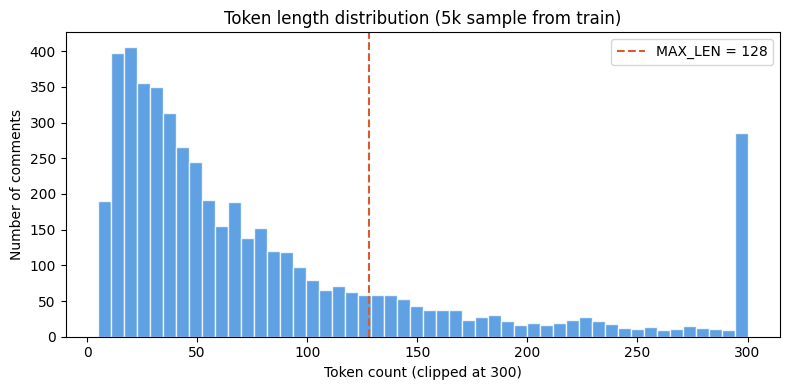

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lens.clip(upper=300), bins=50, color="#378ADD", alpha=0.8, edgecolor="white")
ax.axvline(MAX_LEN, color="#D85A30", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
ax.set_xlabel("Token count (clipped at 300)")
ax.set_ylabel("Number of comments")
ax.set_title("Token length distribution (5k sample from train)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "distilbert_token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Fine-tune DistilBERT

Key choices:
- **3 epochs** — standard for BERT fine-tuning; more tends to overfit
- **lr = 2e-5** — the canonical learning rate for BERT fine-tuning
- **Weighted cross-entropy loss** — handles the 9:1 class imbalance
- **Gradient clipping** — prevents exploding gradients when adapting to a new domain
- **Best checkpoint** by validation F1 is automatically saved

Training takes ~15-30 min on a GPU, longer on CPU.

In [11]:
model, tokenizer, history = train_distilbert(
    train,
    val,
    batch_size=32,
    epochs=3,
    lr=2e-5,
)

Device: mps


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights: [0.5566001534461975, 4.916949272155762]


Epoch 1/3  |  train loss: 0.2488  |  val loss: 0.2282  |  val F1 (toxic): 0.8222
  New best — saving checkpoint.


Epoch 2/3  |  train loss: 0.1551  |  val loss: 0.2180  |  val F1 (toxic): 0.8079


Epoch 3/3  |  train loss: 0.1025  |  val loss: 0.3362  |  val F1 (toxic): 0.8294
  New best — saving checkpoint.

Training done. Best val F1: 0.8294


Training curves saved → /Users/ishaqbreiwish/Documents/Spring_26/Projects/toxic-classification/results/distilbert_training_curves.png


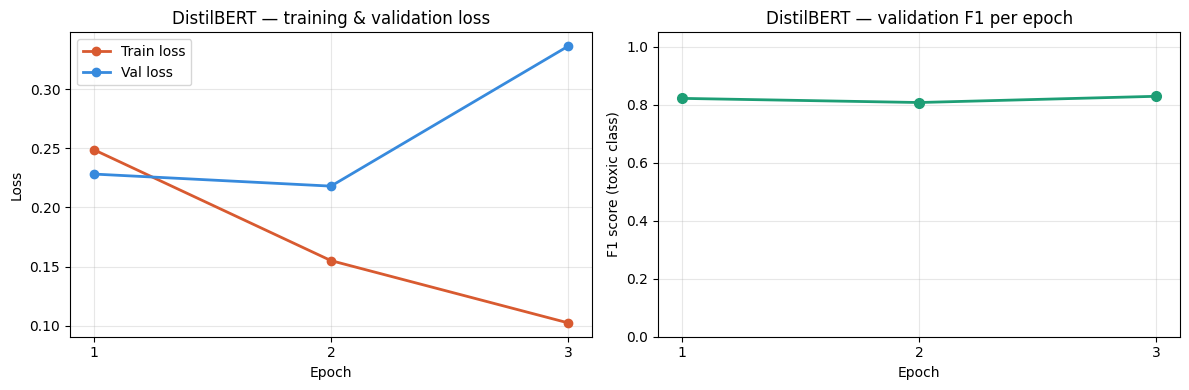

In [12]:
plot_training_curves(history)

## 3. Evaluate on validation set


  DistilBERT (val)
              precision    recall  f1-score   support

   non-toxic     0.9829    0.9775    0.9802     14333
       toxic     0.8101    0.8496    0.8294      1622

    accuracy                         0.9645     15955
   macro avg     0.8965    0.9135    0.9048     15955
weighted avg     0.9653    0.9645    0.9648     15955



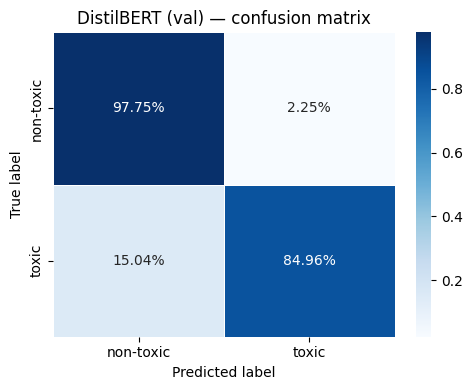

ROC-AUC: 0.9823


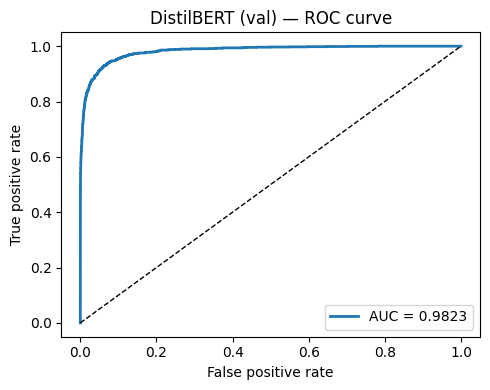

In [13]:
val_preds, val_probs = predict(model, tokenizer, val)
val_results = evaluate(
    val["label"].values,
    val_preds,
    model_name="DistilBERT (val)",
    y_prob=val_probs,
)

## 4. Evaluate on test set


  DistilBERT
              precision    recall  f1-score   support

   non-toxic     0.9836    0.9754    0.9795     14335
       toxic     0.7975    0.8564    0.8259      1623

    accuracy                         0.9633     15958
   macro avg     0.8905    0.9159    0.9027     15958
weighted avg     0.9647    0.9633    0.9639     15958



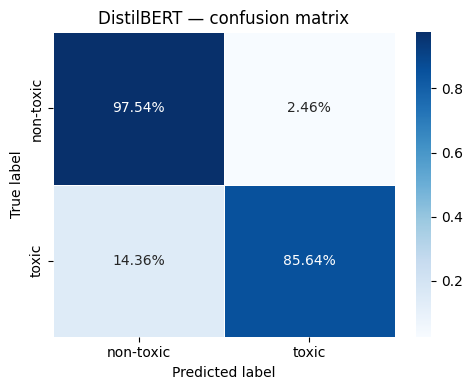

ROC-AUC: 0.9840


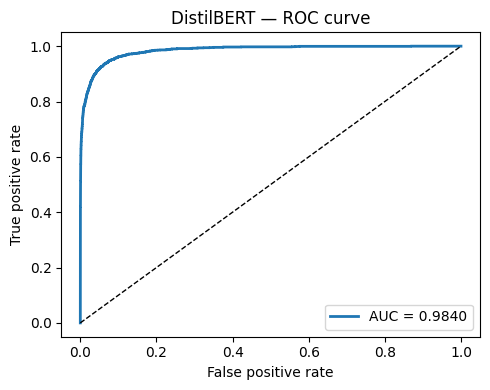


Test results: {'model': 'DistilBERT', 'f1_toxic': 0.8259, 'precision_toxic': 0.7975, 'recall_toxic': 0.8564, 'f1_nontoxic': 0.9795, 'f1_macro': 0.9027, 'f1_weighted': 0.9639, 'roc_auc': np.float64(0.984)}


In [14]:
test_preds, test_probs = predict(model, tokenizer, test)
test_results = evaluate(
    test["label"].values,
    test_preds,
    model_name="DistilBERT",
    y_prob=test_probs,
)
print("\nTest results:", test_results)

## 5. Save predictions, results, and model

In [15]:
# Save predictions CSV (used by error_analysis.ipynb)
test_out = test.copy()
test_out["distilbert_pred"] = test_preds
test_out["distilbert_prob"] = test_probs.round(6)
test_out.to_csv(RESULTS_DIR / "test_distilbert_preds.csv", index=False)
print(f"Predictions saved -> {RESULTS_DIR / 'test_distilbert_preds.csv'}")

# Save results JSON (used by evaluation comparison notebook)
test_results["epochs"]     = 3
test_results["lr"]         = 2e-5
test_results["batch_size"] = 32
test_results["history"]    = history
with open(RESULTS_DIR / "distilbert_results.json", "w") as f:
    json.dump(test_results, f, indent=2)
print(f"Results saved     -> {RESULTS_DIR / 'distilbert_results.json'}")

Predictions saved -> ../results/test_distilbert_preds.csv
Results saved     -> ../results/distilbert_results.json


In [16]:
# Save model weights
save_model(model, tokenizer, models_dir="../models")

Model saved → ../models/distilbert_finetuned


In [17]:
# Save false positive / false negative samples for error analysis
errors = extract_errors(test_out, pred_col="distilbert_pred")
errors["false_positives"].to_csv(RESULTS_DIR / "errors_distilbert_fp.csv", index=False)
errors["false_negatives"].to_csv(RESULTS_DIR / "errors_distilbert_fn.csv", index=False)
print(f"Error samples saved -> {RESULTS_DIR}/errors_distilbert_*.csv")

False positives: 353 total  |  50 sampled
False negatives: 233 total  |  50 sampled
Error samples saved -> ../results/errors_distilbert_*.csv


## 6. Quick look at errors

Spot-check some false positives and false negatives to get an intuition for
where the model struggles. Full error analysis is in `error_analysis.ipynb`.

In [18]:
fp = errors["false_positives"]
fn = errors["false_negatives"]

print("=== False Positives (predicted toxic, actually non-toxic) ===")
for _, row in fp.head(5).iterrows():
    prob = test_out.loc[row.name, "distilbert_prob"]
    print(f"  prob={prob:.3f}  |  {str(row['comment_text'])[:200]}")
    print()

print("=== False Negatives (missed toxic comments) ===")
for _, row in fn.head(5).iterrows():
    prob = test_out.loc[row.name, "distilbert_prob"]
    print(f"  prob={prob:.3f}  |  {str(row['comment_text'])[:200]}")
    print()

=== False Positives (predicted toxic, actually non-toxic) ===
  prob=0.787  |  Hello, Nawlins

Place the following in the large text box:

Why do you like to deflower prepubescent girls? Don’t you know that’s a felony?

  prob=0.907  |  "

The best source and the best citation is his own words. If you read the interview Waters says ""(...) if you believe artists should be mute, emasculated, nodding dogs dangling aimlessly over the da

  prob=0.893  |  "

Civility

I don't think you deserve any civility, and your talk page/edit history goes a long way in showing that. You appear to be one of the worst kinds of Israelis/pro-Israel people you're even 

  prob=0.992  |  "

You wrote (a few inches above) you acknowledge that the community doesn’t want “son of autoformatting”  You've also accused him (and Locke Cole) of ""backing away"" from the code UC Bill has been w

  prob=0.900  |  Really? Even when it's so obvious? Fine. I hope you yourself know in your head and heart that you are a ma